# Estimación del Precio de Viviendas mediante Técnicas de Machine Learning (Regresión)

**Caso de Estudio N°11 — Sector Inmobiliario (Lima Metropolitana)**

**Curso:** Sistemas Inteligentes y Machine Learning

**Integrantes:**
1. Castro Rios, Jose Luis
2. Yarihuaman Estrada, Kevin David
3. Camarena Carrasco, Xander Luis Steve
4. Ramos Flores, Junior
5. Calderon Flores, Abdiel

**Objetivo:** Desarrollar un modelo predictivo basado en técnicas de machine learning (regresión) para estimar el precio de las viviendas de un distrito de Lima Metropolitana a partir de sus características, siguiendo la metodología CRISP-DM.

## 1. Importación de librerías

Se utilizan **Pandas** y **NumPy** para la manipulación de datos, **Matplotlib** y **Seaborn** para la visualización, **Scikit-learn** para el preprocesamiento (escalado con `StandardScaler`), entrenamiento y evaluación de modelos, y **XGBoost** como algoritmo de ensamble basado en boosting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

import os
os.makedirs('figs', exist_ok=True)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

## 2. Fase 1: Comprensión del negocio y de los datos

Una empresa inmobiliaria necesita conocer el **precio medio de las casas determinado por sus características** para definir estrategias diferenciadas de venta, políticas de descuento y promociones. La variable objetivo es **Precio** (en dólares) y se trata de un problema de **regresión** (aprendizaje supervisado).

Se trabaja con el conjunto de datos **`DataPrecioVivienda_Aumentado.xlsx`**, que contiene **500 registros** de viviendas. Este dataset se construyó a partir de la base original (128 registros), depurada de valores atípicos y **ampliada mediante generación de datos sintéticos que conservan la estructura de correlaciones** entre las variables.

| Variable | Descripción |
|---|---|
| ID | Identificador único de la vivienda |
| Origen | Trazabilidad del registro (Real / Sintetico) |
| Piescuad | Superficie de la vivienda en pies cuadrados |
| Cuartos | Número de cuartos o habitaciones |
| Baños | Número de baños |
| Ofertas | Número de casas con las mismas características ofertadas en la localidad |
| **Precio** | **Precio de la vivienda (variable objetivo)** |

In [2]:
# Carga del dataset aumentado
df = pd.read_excel('DataPrecioVivienda_Aumentado.xlsx')

# Trazabilidad: cuántos registros son reales y cuántos sintéticos
if 'Origen' in df.columns:
    print('Composición del dataset:')
    print(df['Origen'].value_counts())
    df = df.drop(columns=['Origen'])

df.head(10)

Composición del dataset:
Origen
Sintetico    379
Real         121
Name: count, dtype: int64


,ID,Piescuad,Cuartos,Baños,Ofertas,Precio
0,1,1790,2,2,2,114300
1,2,2030,4,2,3,114200
2,3,1740,3,2,1,114800
3,4,1980,3,2,3,94700
4,5,2130,3,3,3,119800
5,6,1780,3,2,2,114600
6,7,1830,3,3,3,151600
7,8,2160,4,2,2,150700
8,9,2110,4,2,3,119200
9,10,1730,3,3,3,104000


In [3]:
# Estructura general del dataframe
print(f'Registros: {df.shape[0]}  |  Columnas: {df.shape[1]}')
df.info()

Registros: 500  |  Columnas: 6
<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   ID        500 non-null    int64
 1   Piescuad  500 non-null    int64
 2   Cuartos   500 non-null    int64
 3   Baños     500 non-null    int64
 4   Ofertas   500 non-null    int64
 5   Precio    500 non-null    int64
dtypes: int64(6)
memory usage: 23.6 KB


### 2.1. Análisis Exploratorio de Datos (EDA)

El dataset contiene **500 registros**, todos de tipo numérico y **sin valores nulos**. La variable `ID` cumple únicamente una función identificadora, por lo que será eliminada en el modelado.

In [4]:
# Verificación de valores nulos y duplicados
print('Valores nulos por columna:')
print(df.isnull().sum())
print(f'\nRegistros duplicados: {df.duplicated().sum()}')

Valores nulos por columna:
ID          0
Piescuad    0
Cuartos     0
Baños       0
Ofertas     0
Precio      0
dtype: int64

Registros duplicados: 0


In [5]:
# Medidas de tendencia central y dispersión
df.drop(columns=['ID']).describe().T

,count,mean,std,min,25%,50%,75%,max
Piescuad,500.00,"1,992.44",201.24,"1,520.00","1,860.00","1,990.00","2,130.00","2,530.00"
Cuartos,500.00,3.02,0.73,2.00,3.00,3.00,3.00,5.00
Baños,500.00,2.42,0.51,2.00,2.00,2.00,3.00,4.00
Ofertas,500.00,2.46,0.94,1.00,2.00,2.00,3.00,5.00
Precio,500.00,"130,286.20","24,740.79","69,100.00","113,775.00","129,050.00","147,000.00","199,500.00"


In [6]:
# Coeficiente de variación de las variables
cv = (df.drop(columns=['ID']).std(numeric_only=True) / df.drop(columns=['ID']).mean(numeric_only=True) * 100).round(2)
print('Coeficiente de variación (%):')
print(cv)

Coeficiente de variación (%):
Piescuad   10.10
Cuartos    24.04
Baños      21.07
Ofertas    38.21
Precio     18.99
dtype: float64


**Interpretación:** la variable `Piescuad` presenta baja dispersión (CV ≈ 10.1%), mientras que `Precio` muestra una dispersión moderada (CV ≈ 19.0%). `Ofertas` es la variable con mayor variabilidad relativa (CV ≈ 38.2%). Ninguna variable presenta una dispersión extrema que comprometa el modelado.

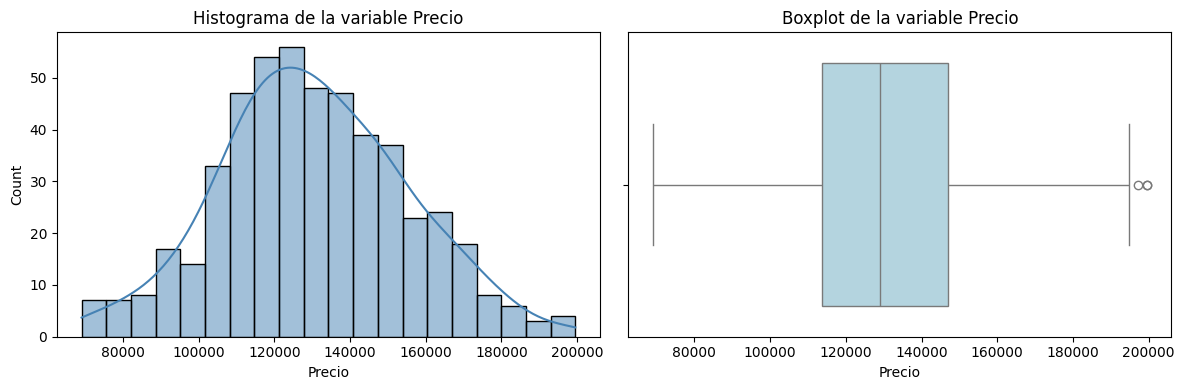

Asimetría (skewness): 0.108


In [7]:
# Análisis de la variable objetivo: Precio
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['Precio'], bins=20, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Histograma de la variable Precio')
sns.boxplot(x=df['Precio'], ax=axes[1], color='lightblue')
axes[1].set_title('Boxplot de la variable Precio')
plt.tight_layout()
plt.savefig('figs/01_precio_dist.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Asimetría (skewness): {df['Precio'].skew():.3f}")

La distribución del precio es aproximadamente normal y prácticamente simétrica (skew ≈ 0.11). Al provenir de un dataset previamente depurado, el boxplot no evidencia valores atípicos extremos que pudieran distorsionar el ajuste de los modelos.

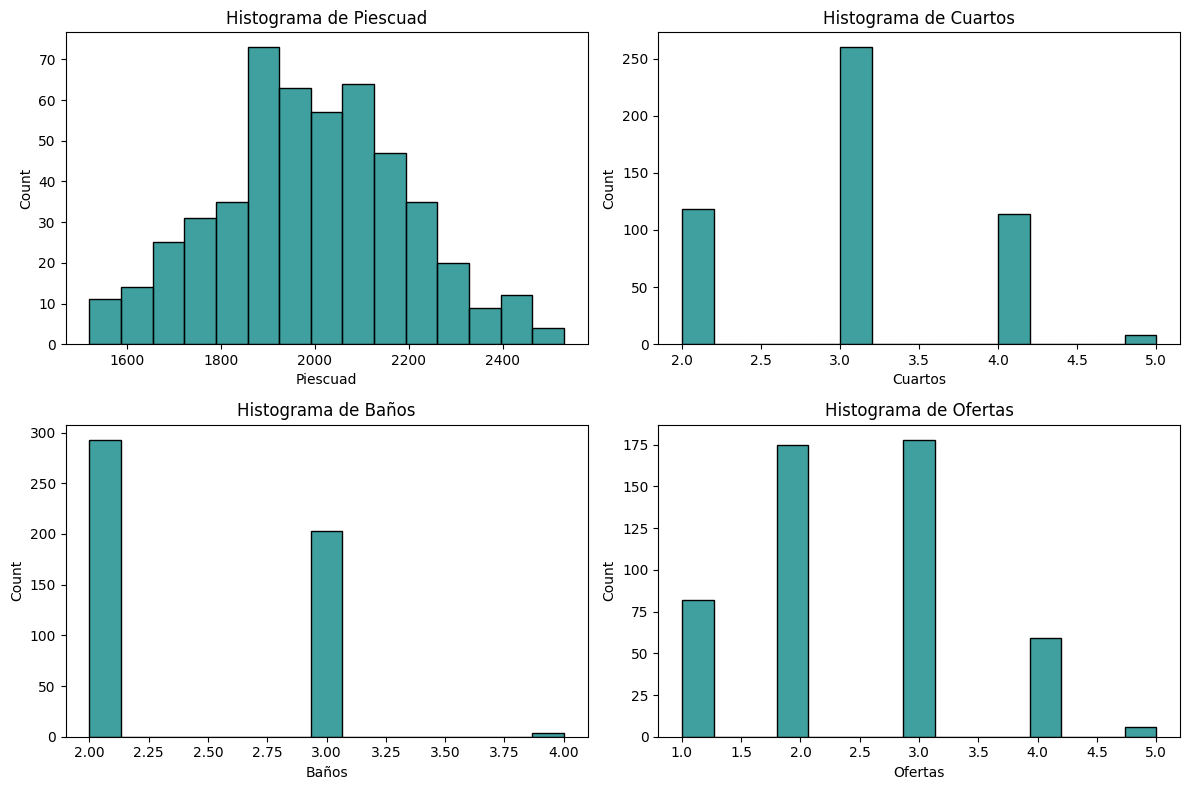

In [8]:
# Histogramas de las variables predictoras
pred_cols = ['Piescuad', 'Cuartos', 'Baños', 'Ofertas']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), pred_cols):
    sns.histplot(df[col], bins=15, ax=ax, color='teal')
    ax.set_title(f'Histograma de {col}')
plt.tight_layout()
plt.savefig('figs/02_hist_predictoras.png', dpi=120, bbox_inches='tight')
plt.show()

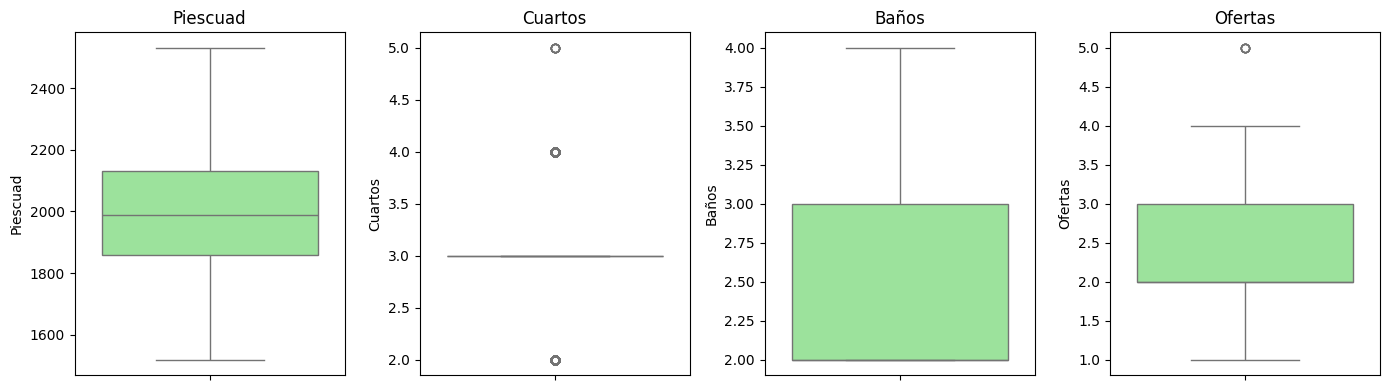

In [9]:
# Boxplots de las variables cuantitativas
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, col in zip(axes, pred_cols):
    sns.boxplot(y=df[col], ax=ax, color='lightgreen')
    ax.set_title(col)
plt.tight_layout()
plt.savefig('figs/03_boxplots.png', dpi=120, bbox_inches='tight')
plt.show()

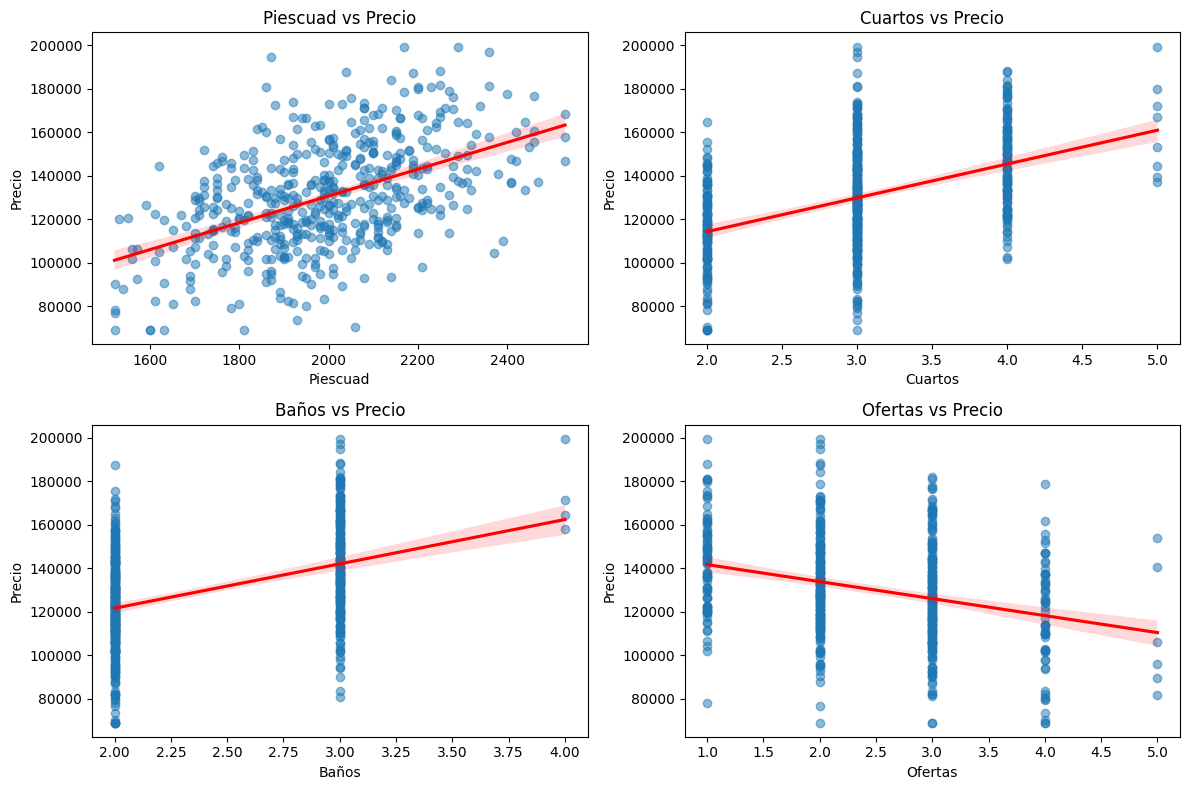

In [10]:
# Relación de cada variable con el precio
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.ravel(), pred_cols):
    sns.regplot(x=df[col], y=df['Precio'], ax=ax,
                scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
    ax.set_title(f'{col} vs Precio')
plt.tight_layout()
plt.savefig('figs/04_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

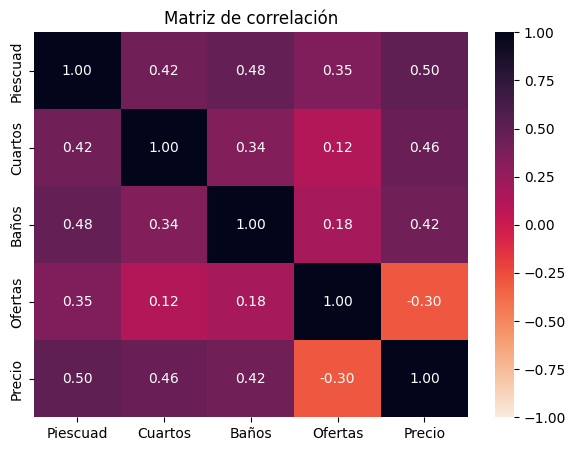

In [11]:
# Matriz de correlación
plt.figure(figsize=(7, 5))
corr = df.drop(columns=['ID']).corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='rocket_r', vmin=-1, vmax=1)
plt.title('Matriz de correlación')
plt.savefig('figs/05_correlacion.png', dpi=120, bbox_inches='tight')
plt.show()

**Interpretación de la matriz de correlación:**
- `Piescuad` (superficie) tiene la correlación positiva más alta con el precio (**0.50**): a mayor superficie, mayor precio.
- `Cuartos` (**0.46**) y `Baños` (**0.42**) también muestran asociaciones positivas moderadas con el precio.
- `Ofertas` presenta una correlación **negativa** (**-0.30**): a mayor número de viviendas similares ofertadas en la localidad (mayor competencia), menor precio, lo cual es coherente con la ley de oferta y demanda.

## 3. Fase 2: Preparación de los datos

El dataset de trabajo ya se encuentra **depurado de valores atípicos y aumentado a 500 registros**. En esta fase se completan los pasos restantes previos al modelado:

1. **Ingeniería de características (*feature engineering*)**: creación de variables derivadas.
2. **Escalamiento** de las variables con `StandardScaler`.
3. **División** del conjunto en entrenamiento (80%) y prueba (20%).

La variable `ID` se elimina por no aportar valor predictivo. No se requiere imputación (no hay nulos) ni codificación (todas las variables son numéricas).

### 3.1. Ingeniería de características

Se construyen dos variables derivadas que aportan información estructural de la vivienda, **sin utilizar la variable objetivo** (para evitar fuga de información o *data leakage*):

- **`Area_x_Cuarto`** = `Piescuad` / `Cuartos` → superficie promedio por habitación.
- **`Ratio_Banos_Cuartos`** = `Baños` / `Cuartos` → equipamiento sanitario relativo.

In [12]:
# Creación de variables derivadas
df['Area_x_Cuarto'] = (df['Piescuad'] / df['Cuartos']).round(1)
df['Ratio_Banos_Cuartos'] = (df['Baños'] / df['Cuartos']).round(3)
df[['Piescuad','Cuartos','Baños','Area_x_Cuarto','Ratio_Banos_Cuartos','Precio']].head()

,Piescuad,Cuartos,Baños,Area_x_Cuarto,Ratio_Banos_Cuartos,Precio
0,1790,2,2,895.00,1.00,114300
1,2030,4,2,507.50,0.50,114200
2,1740,3,2,580.00,0.67,114800
3,1980,3,2,660.00,0.67,94700
4,2130,3,3,710.00,1.00,119800


### 3.2. Separación, división y escalamiento

Se separan las variables independientes (X) y la objetivo (y), se divide en entrenamiento (80%) y prueba (20%), y se **estandarizan** las variables con `StandardScaler` (media 0, desviación 1). El escalador se ajusta **solo con los datos de entrenamiento** y luego se aplica al conjunto de prueba, evitando fuga de información.

In [13]:
# Variables predictoras (incluye las derivadas) y objetivo
features = ['Piescuad', 'Cuartos', 'Baños', 'Ofertas', 'Area_x_Cuarto', 'Ratio_Banos_Cuartos']
X = df[features]
y = df['Precio']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_SEED)

# Escalamiento estándar (fit solo en train)
scaler = StandardScaler().fit(X_train)
X_train = pd.DataFrame(scaler.transform(X_train), columns=features, index=X_train.index)
X_test  = pd.DataFrame(scaler.transform(X_test),  columns=features, index=X_test.index)

print(f'X_train: {X_train.shape} | X_test: {X_test.shape}')
print(f'y_train: {y_train.shape} | y_test: {y_test.shape}')

X_train: (400, 6) | X_test: (100, 6)
y_train: (400,) | y_test: (100,)


## 4. Fase 3: Modelado (Entrenamiento)

Se entrenan y comparan cuatro algoritmos de regresión sobre el dataset escalado:

1. **Regresión Lineal Múltiple** — modelo base interpretable.
2. **Árbol de Decisión (Regresor)** — reglas explícitas, con ajuste de hiperparámetros.
3. **Random Forest (Regresor)** — ensamble por bagging, sin y con tuneo.
4. **XGBoost (Regresor)** — ensamble por boosting, sin y con tuneo.

La evaluación se realiza con las métricas **R²**, **RMSE** y **MAE** sobre el conjunto de prueba.

In [14]:
# Función auxiliar de evaluación
def evaluar(nombre, modelo, X_te=X_test, y_te=y_test):
    y_pred = modelo.predict(X_te)
    r2 = r2_score(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae = mean_absolute_error(y_te, y_pred)
    print(f'{nombre}')
    print(f'  R2   : {r2:.4f}')
    print(f'  RMSE : {rmse:,.2f}')
    print(f'  MAE  : {mae:,.2f}')
    return {'Modelo': nombre, 'R2': round(r2, 4),
            'RMSE': round(rmse, 2), 'MAE': round(mae, 2)}

resultados = []

### 4.1. Regresión Lineal Múltiple

Al estar las variables **estandarizadas**, cada coeficiente representa el cambio en el precio (USD) asociado a un aumento de **una desviación estándar** en la variable, lo que permite comparar directamente la importancia de cada predictor.

In [15]:
modelo_lr = LinearRegression()
modelo_lr.fit(X_train, y_train)
resultados.append(evaluar('Regresión Lineal', modelo_lr))

print('\nCoeficientes estandarizados:')
coefs = pd.DataFrame({'Variable': features, 'Coeficiente': modelo_lr.coef_}) \
        .sort_values('Coeficiente', key=abs, ascending=False)
print(coefs.to_string(index=False))
print(f'Intercepto: {modelo_lr.intercept_:,.2f}')

Regresión Lineal
  R2   : 0.4723
  RMSE : 15,909.01
  MAE  : 12,743.79

Coeficientes estandarizados:
           Variable  Coeficiente
           Piescuad    14,394.40
            Ofertas   -14,394.23
              Baños     5,685.29
      Area_x_Cuarto    -2,742.46
            Cuartos     1,192.75
Ratio_Banos_Cuartos      -753.12
Intercepto: 130,185.25


**Interpretación de los coeficientes (estandarizados):** `Piescuad` y `Ofertas` son los predictores de mayor peso. Un aumento de una desviación estándar en la superficie eleva el precio en ≈ 14.4 mil dólares, mientras que una desviación estándar adicional de `Ofertas` (mayor competencia) lo **reduce** en una magnitud similar. Los baños aportan positivamente y las variables derivadas tienen un efecto marginal.

### 4.2. Árbol de Decisión (Regresor)

El árbol divide recursivamente el espacio de variables minimizando el error cuadrático (criterio MSE). Se ajustan la profundidad máxima y el mínimo de muestras por hoja mediante `GridSearchCV` (validación cruzada de 5 particiones) para controlar el sobreajuste.

In [16]:
# Árbol de decisión sin tuneo
modelo_dt = DecisionTreeRegressor(random_state=RANDOM_SEED)
modelo_dt.fit(X_train, y_train)
resultados.append(evaluar('Árbol de Decisión (Sin Tuneo)', modelo_dt))

Árbol de Decisión (Sin Tuneo)
  R2   : -0.1061
  RMSE : 23,033.10
  MAE  : 19,044.00


In [17]:
# Árbol de decisión con tuneo de hiperparámetros
param_dt = {'max_depth': [2, 3, 4, 5, 6],
            'min_samples_leaf': [2, 4, 6, 8, 10],
            'min_samples_split': [2, 5, 10]}
grid_dt = GridSearchCV(DecisionTreeRegressor(random_state=RANDOM_SEED),
                       param_dt, cv=5, scoring='r2', n_jobs=-1)
grid_dt.fit(X_train, y_train)
print('Mejores hiperparámetros:', grid_dt.best_params_)
modelo_dt_t = grid_dt.best_estimator_
resultados.append(evaluar('Árbol de Decisión (Con Tuneo)', modelo_dt_t))

Mejores hiperparámetros: {'max_depth': 6, 'min_samples_leaf': 6, 'min_samples_split': 2}
Árbol de Decisión (Con Tuneo)
  R2   : 0.2021
  RMSE : 19,562.20
  MAE  : 16,724.30


### 4.3. Random Forest (Regresor)

Random Forest entrena múltiples árboles sobre muestras bootstrap con subconjuntos aleatorios de variables y promedia sus predicciones, reduciendo la varianza del árbol individual.

In [18]:
# Random Forest sin tuneo
modelo_rf = RandomForestRegressor(random_state=RANDOM_SEED)
modelo_rf.fit(X_train, y_train)
resultados.append(evaluar('Random Forest (Sin Tuneo)', modelo_rf))

Random Forest (Sin Tuneo)
  R2   : 0.2425
  RMSE : 19,060.35
  MAE  : 16,168.33


In [19]:
# Random Forest con tuneo de hiperparámetros
param_rf = {'n_estimators': [100, 200, 400],
            'max_depth': [3, 5, 7, None],
            'min_samples_leaf': [1, 2, 4]}
grid_rf = GridSearchCV(RandomForestRegressor(random_state=RANDOM_SEED),
                       param_rf, cv=5, scoring='r2', n_jobs=-1)
grid_rf.fit(X_train, y_train)
print('Mejores hiperparámetros:', grid_rf.best_params_)
modelo_rf_t = grid_rf.best_estimator_
resultados.append(evaluar('Random Forest (Con Tuneo)', modelo_rf_t))

Mejores hiperparámetros: {'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 400}
Random Forest (Con Tuneo)
  R2   : 0.3742
  RMSE : 17,324.44
  MAE  : 14,407.48


### 4.4. XGBoost (Regresor)

XGBoost construye árboles de forma secuencial: cada nuevo árbol corrige los errores residuales del ensamble anterior mediante gradient boosting con regularización.

In [20]:
# XGBoost sin tuneo
modelo_xgb = XGBRegressor(random_state=RANDOM_SEED, verbosity=0)
modelo_xgb.fit(X_train, y_train)
resultados.append(evaluar('XGBoost (Sin Tuneo)', modelo_xgb))

XGBoost (Sin Tuneo)
  R2   : 0.1952
  RMSE : 19,647.56
  MAE  : 16,669.53


In [21]:
# XGBoost con tuneo de hiperparámetros
param_xgb = {'n_estimators': [100, 200, 400],
             'max_depth': [2, 3, 4],
             'learning_rate': [0.03, 0.05, 0.1],
             'subsample': [0.8, 1.0]}
grid_xgb = GridSearchCV(XGBRegressor(random_state=RANDOM_SEED, verbosity=0),
                        param_xgb, cv=5, scoring='r2', n_jobs=-1)
grid_xgb.fit(X_train, y_train)
print('Mejores hiperparámetros:', grid_xgb.best_params_)
modelo_xgb_t = grid_xgb.best_estimator_
resultados.append(evaluar('XGBoost (Con Tuneo)', modelo_xgb_t))

Mejores hiperparámetros: {'learning_rate': 0.05, 'max_depth': 2, 'n_estimators': 200, 'subsample': 0.8}
XGBoost (Con Tuneo)
  R2   : 0.4295
  RMSE : 16,541.88
  MAE  : 13,732.42


## 5. Fase 4: Evaluación y comparación de modelos

In [22]:
# Tabla comparativa de modelos
tabla = pd.DataFrame(resultados).sort_values('R2', ascending=False).reset_index(drop=True)
tabla

,Modelo,R2,RMSE,MAE
0,Regresión Lineal,0.47,"15,909.01","12,743.79"
1,XGBoost (Con Tuneo),0.43,"16,541.88","13,732.42"
2,Random Forest (Con Tuneo),0.37,"17,324.44","14,407.48"
3,Random Forest (Sin Tuneo),0.24,"19,060.35","16,168.33"
4,Árbol de Decisión (Con Tuneo),0.20,"19,562.20","16,724.30"
5,XGBoost (Sin Tuneo),0.20,"19,647.56","16,669.53"
6,Árbol de Decisión (Sin Tuneo),-0.11,"23,033.10","19,044.00"


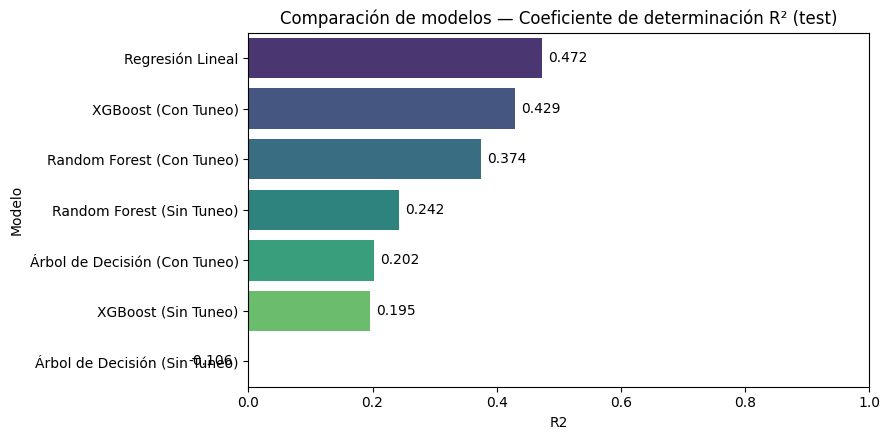

In [23]:
# Gráfico comparativo de R2
plt.figure(figsize=(9, 4.5))
sns.barplot(data=tabla, x='R2', y='Modelo', hue='Modelo', palette='viridis', legend=False)
plt.title('Comparación de modelos — Coeficiente de determinación R² (test)')
plt.xlim(0, 1)
for i, v in enumerate(tabla['R2']):
    plt.text(v + 0.01, i, f'{v:.3f}', va='center')
plt.tight_layout()
plt.savefig('figs/06_comparacion_r2.png', dpi=120, bbox_inches='tight')
plt.show()

In [24]:
# Selección del mejor modelo
mejor_nombre = tabla.iloc[0]['Modelo']
mapa = {'Regresión Lineal': modelo_lr,
        'Árbol de Decisión (Sin Tuneo)': modelo_dt,
        'Árbol de Decisión (Con Tuneo)': modelo_dt_t,
        'Random Forest (Sin Tuneo)': modelo_rf,
        'Random Forest (Con Tuneo)': modelo_rf_t,
        'XGBoost (Sin Tuneo)': modelo_xgb,
        'XGBoost (Con Tuneo)': modelo_xgb_t}
mejor_modelo = mapa[mejor_nombre]
print(f'Mejor modelo: {mejor_nombre}')

Mejor modelo: Regresión Lineal


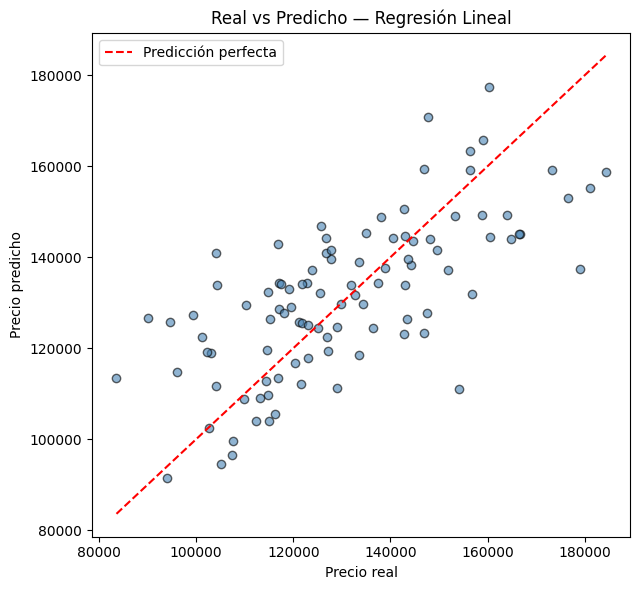

In [25]:
# Valores reales vs predichos del mejor modelo
y_pred_best = mejor_modelo.predict(X_test)
plt.figure(figsize=(6.5, 6))
plt.scatter(y_test, y_pred_best, alpha=0.6, color='steelblue', edgecolor='k')
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
plt.plot(lims, lims, 'r--', label='Predicción perfecta')
plt.xlabel('Precio real')
plt.ylabel('Precio predicho')
plt.title(f'Real vs Predicho — {mejor_nombre}')
plt.legend()
plt.tight_layout()
plt.savefig('figs/07_real_vs_pred.png', dpi=120, bbox_inches='tight')
plt.show()

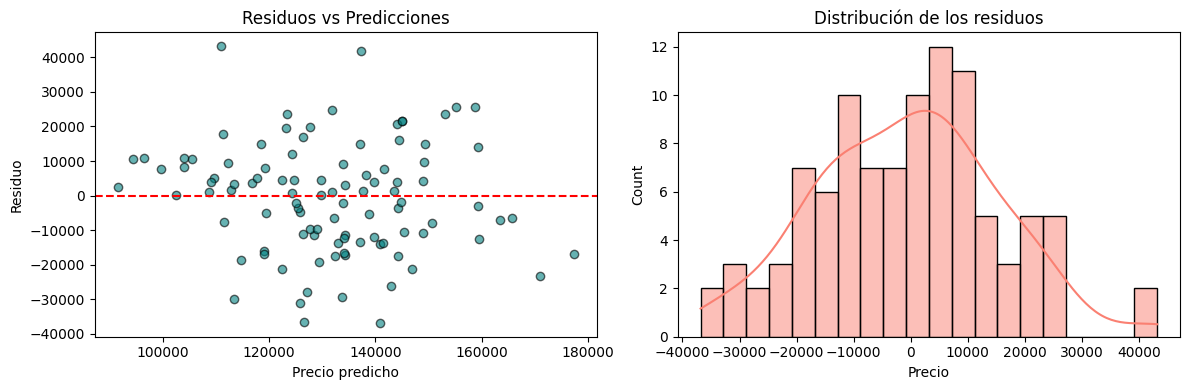

In [26]:
# Análisis de residuos del mejor modelo
residuos = y_test - y_pred_best
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_pred_best, residuos, alpha=0.6, color='teal', edgecolor='k')
axes[0].axhline(0, color='red', ls='--')
axes[0].set_xlabel('Precio predicho'); axes[0].set_ylabel('Residuo')
axes[0].set_title('Residuos vs Predicciones')
sns.histplot(residuos, bins=20, kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribución de los residuos')
plt.tight_layout()
plt.savefig('figs/08_residuos.png', dpi=120, bbox_inches='tight')
plt.show()

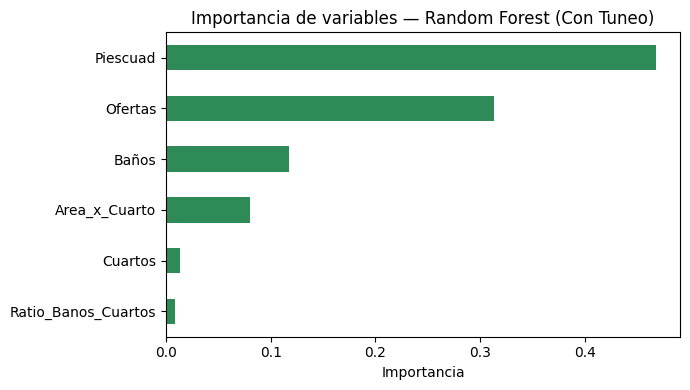

Piescuad              0.47
Ofertas               0.31
Baños                 0.12
Area_x_Cuarto         0.08
Cuartos               0.01
Ratio_Banos_Cuartos   0.01
dtype: float64


In [27]:
# Importancia de variables (Random Forest tuneado)
imp = pd.Series(modelo_rf_t.feature_importances_, index=features).sort_values()
plt.figure(figsize=(7, 4))
imp.plot(kind='barh', color='seagreen')
plt.title('Importancia de variables — Random Forest (Con Tuneo)')
plt.xlabel('Importancia')
plt.tight_layout()
plt.savefig('figs/09_importancia.png', dpi=120, bbox_inches='tight')
plt.show()
print(imp.sort_values(ascending=False))

## 6. Fase 5: Predicción con nuevos registros (Despliegue)

Se simula el comportamiento del modelo en un escenario real con dos viviendas ficticias. Las nuevas observaciones pasan por **el mismo preprocesamiento** del entrenamiento: cálculo de variables derivadas y escalamiento con el `scaler` ya ajustado.

- **Vivienda A:** 1,700 pies², 2 cuartos, 2 baños, 4 ofertas similares (perfil de gama media-baja con alta competencia).
- **Vivienda B:** 2,400 pies², 4 cuartos, 3 baños, 1 oferta similar (perfil de gama alta con baja competencia).

In [28]:
nuevas = pd.DataFrame({
    'Piescuad': [1700, 2400],
    'Cuartos':  [2, 4],
    'Baños':    [2, 3],
    'Ofertas':  [4, 1]})

# Mismo preprocesamiento: feature engineering + escalado
nuevas['Area_x_Cuarto'] = (nuevas['Piescuad'] / nuevas['Cuartos']).round(1)
nuevas['Ratio_Banos_Cuartos'] = (nuevas['Baños'] / nuevas['Cuartos']).round(3)
nuevas_sc = pd.DataFrame(scaler.transform(nuevas[features]), columns=features)

nuevas['Precio_Estimado'] = mejor_modelo.predict(nuevas_sc).round(0)
nuevas

,Piescuad,Cuartos,Baños,Ofertas,Area_x_Cuarto,Ratio_Banos_Cuartos,Precio_Estimado
0,1700,2,2,4,850.00,1.00,"77,118.00"
1,2400,4,3,1,600.00,0.75,"191,107.00"


## 7. Conclusiones

1. **OE1 (Situación actual):** la empresa carecía de una herramienta cuantitativa para fijar precios; el EDA confirmó que la superficie (`Piescuad`, r = 0.50), los cuartos (r = 0.46) y los baños (r = 0.42) son los principales determinantes positivos del precio, mientras que la competencia (`Ofertas`, r = -0.30) lo presiona a la baja.
2. **OE2 (Preparación y diseño):** se trabajó sobre un dataset depurado de outliers y aumentado a **500 registros conservando la estructura de correlaciones**, sobre el que se aplicó ingeniería de características y escalamiento estándar antes de entrenar cuatro algoritmos con ajuste de hiperparámetros (validación cruzada de 5 particiones).
3. **OE3 (Modelado y resultados):** la **Regresión Lineal Múltiple** obtuvo el mejor desempeño en prueba (R² ≈ 0.47, RMSE ≈ 15.9 mil USD, MAE ≈ 12.7 mil USD), seguida de XGBoost tuneado (R² ≈ 0.43). Al predominar relaciones lineales, los modelos de ensamble no superan al modelo lineal, que además es plenamente interpretable.
4. **OG (Patrones y mejora):** con las variables estandarizadas, la superficie y la competencia (`Ofertas`) son los factores de mayor impacto sobre el precio (≈ ±14 mil USD por desviación estándar), seguidos de los baños. Esto permite a la empresa estimar precios competitivos, ajustar a la baja en zonas saturadas de oferta y capitalizar la superficie y los baños como argumentos de valor.